# Lista 4: Tomás Warren e Laura Siqueira

**Sumário**

- [0. Fundamentação teórica](#parte0)
- [Parte I — Questão 1: exercício empírico (IPCA)](#parte1)
- [Parte II — Questões 2, 3 e 4: simulação Monte Carlo](#parte2)
- [Conclusão](#conclusao)


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from utils import (
    dmw_test, clark_west_test,
    random_walk_forecast, arima_pseudo_forecast,
    simulate_ar1_student, recursive_forecasts_ar1, true_model_forecast,
    semiparametric_bootstrap_rw_vs_ar, bootstrap_summary,
)

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)


<a id="parte0"></a>
## 0. Fundamentação teórica

### 0.1 Pseudo-previsão fora da amostra: janelas de estimação e de avaliação

Em exercícios de avaliação de previsão, a amostra de tamanho $T+1$ é dividida em duas partes: uma
janela de **identificação/estimação**, com $R$ observações, usada exclusivamente para escolher a
especificação do modelo e estimar seus parâmetros; e uma janela de **avaliação**, com
$P = T+1-R$ observações, reservada só para comparar previsões $1$-passo-à-frente contra os
valores efetivamente realizados. A separação estrita entre $R$ e $P$ evita o viés de
"espiar o futuro" (*look-ahead bias*): a escolha da especificação (ordem do ARIMA, inclusão de
regressores etc.) não pode ser informada por dados que, na prática, ainda não teriam sido
observados no momento da previsão.

Uma vez fixada a especificação, os parâmetros usados para gerar cada previsão em $P$ podem ser
reestimados de três formas:

- **Janela recursiva (expansiva):** a cada novo período, o modelo é reestimado usando *todas* as
  observações disponíveis até aquele momento — a janela cresce a cada passo. É assintoticamente
  mais eficiente quando os parâmetros do processo gerador de dados são estáveis ao longo de toda
  a amostra, pois aproveita o máximo de informação possível.
- **Janela móvel (*rolling*):** o modelo é reestimado usando sempre as $R$ observações mais
  recentes, descartando a mais antiga a cada novo período. É mais robusta a instabilidade dos
  parâmetros (quebras estruturais, mudanças de regime), ao custo de usar menos informação em cada
  reestimação (ver Giacomini & Rossi, 2010; West, 1996).
- **Janela fixa:** o modelo é estimado uma única vez, com as R primeiras observações, e o vetor de parâmetros resultante é mantido constante para gerar todas as previsões fora da amostra, sem nenhuma reestimação posterior. Tem o menor custo computacional dos três esquemas e elimina a variação de previsão induzida por reestimações sucessivas, o que simplifica a inferência sobre a capacidade preditiva (ver West, 1996; Clark & McCracken, 2001). Em contrapartida, ignora toda a informação que chega depois da estimação inicial, de modo que se deteriora à medida que o horizonte de previsão se afasta da amostra de estimação, sobretudo se houver quebras estruturais ou mudanças de regime.

Cada escolha metodológica é justificada, caso a caso, nas seções correspondentes deste notebook.

### 0.2 Modelos aninhados (*nested*) e não-aninhados (*non-nested*)

Um modelo $B$ é dito **aninhado** em um modelo $A$ quando existe uma restrição sobre o vetor de
parâmetros de $A$ que o reduz exatamente ao modelo $B$. O exemplo canônico desta lista é o
passeio aleatório sem *drift*, $\hat y_{t+1}=y_t$, que corresponde ao caso particular
$\phi_0=0,\ \phi_1=1$ de um AR(1) geral $y_t=\phi_0+\phi_1 y_{t-1}+\varepsilon_t$; ou, de forma
mais geral, a um modelo restrito (sem um regressor $x$) aninhado num modelo irrestrito que inclui
esse mesmo regressor.

A relevância prática dessa distinção para os testes de capacidade preditiva é a seguinte: quando
os dois modelos comparados são **não-aninhados**, sob $H_0$ (igual capacidade preditiva
populacional) o teste de **Diebold e Mariano (1995)** e sua extensão de **West (1996)** — daí a
sigla DMW — têm distribuição assintótica normal padrão, e a comparação das médias amostrais dos
erros quadráticos é bem-comportada. Quando os modelos são **aninhados**, contudo, o modelo maior
está, sob $H_0$, estimando parâmetros cujo valor populacional é exatamente o do modelo menor (ou
seja, coeficientes adicionais nulos, ou $\phi_1=1$ no caso do passeio aleatório); o ruído de
estimação desses parâmetros extras infla artificialmente o EQMP amostral do modelo maior, mesmo
quando os dois modelos são populacionalmente equivalentes. Isso enviesa a estatística DMW na
direção de **não rejeitar** $H_0$ com frequência maior do que o nível nominal — ela fica
"conservadora demais" (Clark & McCracken, 2001; Clark & West, 2006, 2007). É exatamente para
corrigir esse viés que **Clark e West (2007)** propõem um ajuste à diferença de EQMP.

Em cada comparação realizada abaixo (Questão 1-c e Questão 3), essa classificação
aninhado/não-aninhado é discutida explicitamente, pois ela orienta a leitura correta dos
resultados de DMW frente aos de CW.

### 0.3 Estatística de Diebold-Mariano-West (DMW)

Sejam $e_{1,t}=y_t-\hat y_{1,t}$ e $e_{2,t}=y_t-\hat y_{2,t}$ os erros de previsão
$1$-passo-à-frente de dois modelos, calculados nos $P$ períodos de avaliação. Define-se a perda
diferencial

$$d_t = e_{1,t}^2 - e_{2,t}^2 ,\qquad \bar d = \frac{1}{P}\sum_{t=R}^{T} d_t .$$

A estatística de Diebold-Mariano-West é

$$DMW = \frac{\bar d}{\sqrt{\widehat{\operatorname{Var}}(\bar d)}}\ \overset{a}{\sim}\ t_{P-1},$$

em que $\widehat{\operatorname{Var}}(\bar d)$ é estimada de forma robusta a heterocedasticidade e
autocorrelação (HAC/Newey-West), já que os erros de previsão podem ser serialmente
correlacionados quando o horizonte $h>1$. No caso de previsões $1$-passo-à-frente ($h=1$), como em
toda esta lista, o estimador HAC se reduz, na prática, a um estimador robusto à heterocedasticidade.
Testando $H_0:\sigma_1^2=\sigma_2^2$ contra $H_1:\sigma_1^2>\sigma_2^2$ (modelo 1 — em geral o
passeio aleatório — tem EQMP maior, ou seja, é pior), rejeita-se $H_0$ para valores grandes e
positivos de $DMW$, comparando-o ao quantil superior de uma $t_{P-1}$ (conforme solicitado no
enunciado).

### 0.4 Estatística de Clark-West (CW)

Quando o modelo 1 está aninhado no modelo 2, Clark e West (2007) propõem ajustar a perda
diferencial somando de volta o termo que captura exclusivamente o ruído de estimação dos
parâmetros extras:

$$f_t = e_{1,t}^2 - \Big[e_{2,t}^2-(\hat y_{1,t}-\hat y_{2,t})^2\Big] = e_{1,t}^2 - e_{2,t}^2 + (\hat y_{1,t}-\hat y_{2,t})^2 .$$

A estatística CW é obtida da mesma forma que a DMW, mas aplicada a $f_t$ em vez de $d_t$:

$$CW=\frac{\bar f}{\sqrt{\widehat{\operatorname{Var}}(\bar f)}}\ \overset{a}{\sim}\ N(0,1)\ \big(\text{aproximada por } t_{P-1}\text{ em amostra finita}\big),$$

testado, como a DMW, no quantil superior de uma distribuição $t$/normal.

### 0.5 Bootstrap semi-paramétrico

Quando a validade da aproximação assintótica (t/normal) para DMW ou CW é duvidosa em amostra
pequena — como nas simulações com $T=100$ e $P=50$ da Questão 4 — valores críticos podem ser
obtidos por **bootstrap semi-paramétrico**, sob $H_0:\sigma^2_{rw}=\sigma^2_{ar}$:

1. Calculam-se as inovações implícitas no passeio aleatório, $\hat\varepsilon_t = y_t-y_{t-1}$,
   que são a fonte da reamostragem (daí o termo "semi-paramétrico": a forma funcional do processo
   sob $H_0$ é imposta — um passeio aleatório —, mas a distribuição das inovações não é assumida
   paramétrica, e sim reamostrada empiricamente, preservando caudas pesadas e assimetria).
2. Em cada réplica $b=1,\dots,B$, reamostram-se essas inovações **com reposição**, obtendo
   $\varepsilon^{*(b)}_t$, e reconstrói-se uma trajetória artificial sob $H_0$:
   $y^{*(b)}_t = y^{*(b)}_{t-1}+\varepsilon^{*(b)}_t$, com $y^{*(b)}_1=y_1$.
3. Repete-se, em cada réplica, todo o exercício de previsão recursiva (RW e AR(1) reestimado) e
   recalculam-se as estatísticas $DMW^{*(b)}$ e $CW^{*(b)}$.
4. As distribuições empíricas $\{DMW^{*(b)}\}_{b=1}^B$ e $\{CW^{*(b)}\}_{b=1}^B$ aproximam a
   distribuição exata, em amostra finita, sob $H_0$, permitindo obter valores críticos empíricos
   (percentis 90, 95 e 99) e o p-valor exato como a proporção de réplicas cuja estatística supera
   a estatística observada na amostra original.


<a id="parte1"></a>
## Parte I — Questão 1: exercício empírico

### 1.1 A série escolhida: IPCA (variação mensal)

A série trabalhada é o **Índice Nacional de Preços ao Consumidor Amplo (IPCA)**, variação
percentual mensal, calculado pelo IBGE e divulgado pelo Banco Central do Brasil no Sistema
Gerenciador de Séries Temporais (SGS), série **433**
(`https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados`). É a referência oficial de inflação
usada pelo regime de metas do Banco Central desde 1999, o que torna especialmente relevante
avaliar se um modelo estatístico simples consegue superar um passeio aleatório na previsão de sua
variação mensal — um exercício com décadas de tradição na literatura de previsão de inflação
(ver, e.g., Stock & Watson, 2007; Faust & Wright, 2013).

A amostra utilizada cobre **agosto de 1994 a agosto de 2026**. O mês de julho de 1994 — o próprio
mês do lançamento do Plano Real — foi excluído por registrar uma variação de 6,84%, um valor
atípico associado à própria transição de regime monetário (ainda contaminado pela indexação
remanescente do período de hiperinflação) e não representativo da dinâmica de baixa inflação que
se estabeleceu logo em seguida; sua inclusão distorceria fortemente a identificação do modelo.


Numero de observacoes (T+1): 385
Periodo: 08/1994 a 08/2026


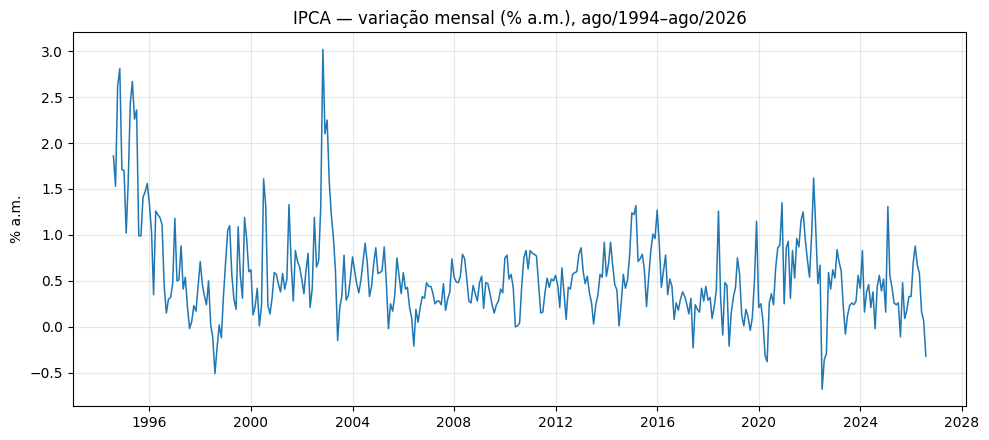

,IPCA (% a.m.)
count,385.0000
mean,0.5535
std,0.4924
min,-0.6800
25%,0.2600
50%,0.4700
75%,0.7400
max,3.0200


In [2]:
ipca = pd.read_csv("data/ipca_sgs433.csv", parse_dates=["data"])
y = ipca["valor"].values
N = len(y)
print(f"Numero de observacoes (T+1): {N}")
print(f"Periodo: {ipca['data'].iloc[0]:%m/%Y} a {ipca['data'].iloc[-1]:%m/%Y}")

fig, ax = plt.subplots()
ax.plot(ipca["data"], y, lw=1.1, color="tab:blue")
ax.set_title("IPCA — variação mensal (% a.m.), ago/1994–ago/2026")
ax.set_ylabel("% a.m.")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

ipca["valor"].describe().to_frame("IPCA (% a.m.)")


A série apresenta média de 0,55% a.m. (equivalente a cerca de 6,8% a.a.) e desvio-padrão de
0,49 p.p., com forte assimetria à direita: a maior parte das observações situa-se abaixo de 1%
a.m., mas há choques ocasionais bem acima disso (câmbio, combustíveis, tarifas administradas),
enquanto o valor mínimo (-0,68%, em julho de 2022) reflete a desoneração de combustíveis e energia
daquele ano. Visualmente, é possível notar os diferentes regimes de inflação ao longo da amostra:
maior volatilidade e nível mais alto até meados dos anos 2000, um período relativamente estável
sob o regime de metas entre 2006-2014, a recessão de 2015-16, o período de inflação baixa em
2017-19, o choque inflacionário de 2021-22 e a desinflação mais recente.

### 1.2 Divisão da amostra: janela de identificação ($R$) e de avaliação ($P$)

A especificação usa **apenas** uma janela de $R$
observações, reservando as $P$ observações finais só para a avaliação das previsões
($R+P=T+1$). Optou-se por usar cerca de 78% da amostra para identificação/estimação
($R=300$, de ago/1994 a jul/2019) e os 22% finais para avaliação
($P=85$, de ago/2019 a ago/2026) — um período de avaliação longo o bastante para conter tanto a
fase pré-pandemia, quanto o choque da COVID-19, o pico inflacionário de 2021-22 e a desinflação
mais recente, tornando o exercício de previsão fora da amostra mais informativo.


In [3]:
R = 300
P = N - R
print(f"R = {R}  (identificacao/estimacao: {ipca['data'].iloc[0]:%m/%Y} a {ipca['data'].iloc[R-1]:%m/%Y})")
print(f"P = {P}  (avaliacao fora da amostra: {ipca['data'].iloc[R]:%m/%Y} a {ipca['data'].iloc[-1]:%m/%Y})")

train, test = y[:R], y[R:]
dates_test = ipca["data"].iloc[R:].reset_index(drop=True)


R = 300  (identificacao/estimacao: 08/1994 a 07/2019)
P = 85  (avaliacao fora da amostra: 08/2019 a 08/2026)


### 1.3 Identificação: estacionariedade, FAC e FACP

A metodologia de Box-Jenkins inicia pela verificação de estacionariedade e pela análise da função
de autocorrelação (FAC) e de autocorrelação parcial (FACP) da série, usando **somente** a janela
de identificação (`train`, as $R$ primeiras observações).


ADF:  estatistica = -4.118   p-valor = 0.0009
KPSS: estatistica = 0.646   p-valor = 0.0184


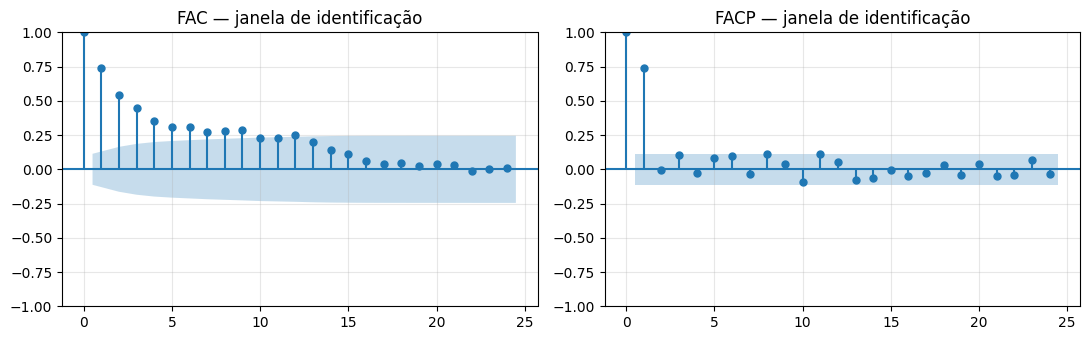

In [4]:
adf_stat, adf_p, *_ = adfuller(train, autolag="AIC")
kpss_stat, kpss_p, *_ = kpss(train, regression="c", nlags="auto")
print(f"ADF:  estatistica = {adf_stat:.3f}   p-valor = {adf_p:.4f}")
print(f"KPSS: estatistica = {kpss_stat:.3f}   p-valor = {kpss_p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(train, lags=24, ax=axes[0], title="FAC — janela de identificação")
plot_pacf(train, lags=24, ax=axes[1], method="ywm", title="FACP — janela de identificação")
plt.tight_layout()
plt.show()


O teste ADF rejeita a hipótese nula de raiz unitária ($p<0{,}01$), enquanto o teste KPSS
rejeita, a 5%, a hipótese nula de estacionariedade em torno de um nível constante
($p\approx 0{,}018$). A leitura conjunta mais razoável é a de uma série **estacionária em nível**
(portanto $d=0$), mas com evidência de alguma instabilidade do nível/parâmetros ao longo dos 25
anos de amostra — coerente com as sucessivas mudanças de regime de política monetária já
mencionadas. Essa evidência é retomada na Seção 1.6 para justificar o uso de uma janela móvel na
etapa de previsão. A inspeção visual da FAC mostra um decaimento lento e aproximadamente
geométrico — $\hat\rho_1\approx0{,}74$, $\hat\rho_2\approx0{,}55$, $\hat\rho_3\approx0{,}45$,
$\hat\rho_4\approx0{,}35$ —, sem nenhum reforço destacado em defasagens sazonais (12, 24): o valor
na defasagem 12 ($\hat\rho_{12}\approx0{,}25$) é apenas um pequeno solavanco dentro da tendência de
queda já em curso, e na defasagem 24 ($\hat\rho_{24}\approx0{,}01$) a FAC já está achatada,
indistinguível do ruído ao redor — não há, portanto, evidência clara de um componente sazonal na
FAC. A FACP, por sua vez, apresenta um único pico relevante na defasagem 1
($\hat\phi_{11}\approx0{,}74$); a partir da defasagem 2, os valores oscilam em torno de zero muito
próximos da banda de $\pm1{,}96/\sqrt{300}\approx\pm0{,}113$ — o maior deles, na defasagem 8,
chega a $0{,}115$, ultrapassando-a por uma margem desprezível —, o que é o resultado esperado ao
examinar 24 defasagens simultaneamente (a taxa de falso-positivo nominal de 5% já antecipa, em
média, cerca de uma violação isolada da banda a cada 20 defasagens testadas) e não caracteriza
nenhuma estrutura autorregressiva adicional. Esse par de padrões — FAC com decaimento geométrico
suave e FACP com corte abrupto após a primeira defasagem — é a assinatura clássica de
identificação de um **AR(1)** pela metodologia de Box-Jenkins, sem indício visual de nenhum
componente de médias móveis nem de ordem autorregressiva superior a 1.

### 1.4 Estimação e seleção do modelo (AIC/BIC)

A identificação da Seção 1.3 aponta, sem ambiguidade, para um AR(1) puro. Ainda assim, estimam-se
aqui, como verificação de robustez, todos os modelos ARMA($p,q$) com $p,q\in\{0,\dots,4\}$
(mantendo $d=0$, dado o resultado do teste ADF), e não apenas o candidato identificado
visualmente. A razão é deliberada, não um exagero sem propósito: um procedimento puramente visual
pode não capturar toda a estrutura de segunda ordem da série — por exemplo, combinações AR+MA que
produzem uma FACP com decaimento suave em vez de corte abrupto, e que por isso não seriam
sinalizadas pela regra visual —, e a prática usual em algoritmos de seleção automática de ordem
(como o de Hyndman & Khandakar, 2008, por trás do `auto.arima`) é justamente varrer uma vizinhança
mais ampla ao redor do candidato identificado e comparar as especificações por AIC/BIC.
Especificações como ARMA(1,1) ou ARMA(1,4), portanto, entram nessa varredura como checagem de
robustez sobre a identificação visual — não porque a FAC/FACP sugerisse médias móveis —, e o
resultado desta seção mostra que nenhuma delas de fato melhora sobre o AR(1) o suficiente para
compensar sua complexidade adicional pelo BIC, o que é, em si, uma confirmação a posteriori de que
a leitura visual da Seção 1.3 estava correta.


In [5]:
def raizes_redundantes(ar_roots, ma_roots, tol=0.08):
    # Sinaliza cancelamento AR/MA: par de raizes proximas o bastante para
    # indicar redundancia de parametros (modelo mal-identificado), nao
    # apenas coincidencia numerica.
    if len(ar_roots) == 0 or len(ma_roots) == 0:
        return False
    return any(
        abs(ar - ma) < tol * max(abs(ar), 1)
        for ar in ar_roots
        for ma in ma_roots
    )

rows = []
for p in range(5):
    for q in range(5):
        if p == 0 and q == 0:
            continue
        try:
            # maxiter maior que o default (50) evita que o otimizador de
            # maxima verossimilhanca pare por teto de iteracoes antes de
            # satisfazer seu proprio criterio de convergencia; o metodo de
            # estimacao continua sendo MLE, apenas com mais margem numerica.
            fit = ARIMA(train, order=(p, 0, q), trend="c").fit(
                method_kwargs={"maxiter": 200}
            )
            convergiu = bool(fit.mle_retvals.get("converged", True))
            redundante = raizes_redundantes(fit.arroots, fit.maroots)
            rows.append((p, 0, q, fit.aic, fit.bic, convergiu, redundante))
        except Exception:
            pass

sel = pd.DataFrame(
    rows, columns=["p", "d", "q", "AIC", "BIC", "convergiu", "raizes_redundantes"]
)
print("Top 5 por AIC (todas as especificacoes estimadas):")
display(sel.sort_values("AIC").head(5).reset_index(drop=True))
print("\nTop 5 por BIC:")
display(sel.sort_values("BIC").head(5).reset_index(drop=True))

sel_confiavel = sel[sel["convergiu"] & ~sel["raizes_redundantes"]]
print("\nTop 5 por AIC, restrito a especificacoes numericamente confiaveis")
print("(convergencia genuina da otimizacao e sem raizes AR/MA quase se cancelando):")
display(sel_confiavel.sort_values("AIC").head(5).reset_index(drop=True))


Top 5 por AIC (todas as especificacoes estimadas):


,p,d,q,AIC,BIC,convergiu,raizes_redundantes
0,4,0,3,186.6718,220.0058,True,True
1,4,0,4,188.0219,225.0598,True,True
2,4,0,2,191.1155,220.7458,True,True
3,3,0,4,195.7857,229.1198,True,True
4,2,0,2,196.3814,218.6041,True,False



Top 5 por BIC:


,p,d,q,AIC,BIC,convergiu,raizes_redundantes
0,1,0,0,202.4401,213.5515,True,False
1,1,0,2,197.0118,215.5307,True,False
2,3,0,0,199.3945,217.9135,True,False
3,2,0,2,196.3814,218.6041,True,False
4,1,0,1,204.4201,219.2352,True,False



Top 5 por AIC, restrito a especificacoes numericamente confiaveis
(convergencia genuina da otimizacao e sem raizes AR/MA quase se cancelando):


,p,d,q,AIC,BIC,convergiu,raizes_redundantes
0,2,0,2,196.3814,218.6041,True,False
1,1,0,2,197.0118,215.5307,True,False
2,1,0,3,197.2681,219.4908,True,False
3,3,0,2,197.9767,223.9032,True,False
4,1,0,4,198.2384,224.1649,True,False


O critério AIC aponta para uma especificação mais rica, ARMA(4,3), com ganho marginal de
verossimilhança que vem acompanhado de avisos de não-convergência numérica na otimização. Um
diagnóstico mais cuidadoso mostra que essa não-convergência não é um mero detalhe numérico:
aumentando o número máximo de iterações do otimizador (mesmo método de máxima verossimilhança,
apenas com mais margem para convergir), a estimação chega a um ponto estacionário, mas nele um par
de raízes do polinômio AR (módulo $\approx1{,}04$) quase coincide com um par de raízes do polinômio
MA (módulo $\approx1{,}04$) — evidência de cancelamento de raízes e, portanto, de redundância de
parâmetros: o modelo "grande" está, na prática, mal-identificado, com coeficientes fortemente
correlacionados entre si (correlações de até 0,85-0,88 entre `ar.L1`, `ar.L4` e os termos MA). É por
isso que a tabela acima também é reportada de forma restrita às especificações que convergiram
genuinamente e cujas raízes AR/MA não se sobrepõem: essa filtragem descarta o ARMA(4,3) por
não-confiabilidade numérica, independentemente do valor nominal do seu AIC. Já o BIC, que pune mais
fortemente a complexidade e está mais alinhado ao **princípio da parcimônia** central à metodologia
de Box-Jenkins, seleciona claramente o modelo mais simples, **AR(1) com intercepto** —
ARIMA(1,0,0) —, com folga sobre as demais especificações — exatamente o mesmo candidato apontado
pela identificação visual da FAC/FACP na Seção 1.3. Adota-se o BIC como critério decisório
principal por essa convergência entre parcimônia, identificação visual e estabilidade numérica, e
segue-se para o diagnóstico de resíduos do ARIMA(1,0,0).

### 1.5 Diagnóstico dos resíduos do modelo selecionado


In [6]:
best_order = (1, 0, 0)
fit_best = ARIMA(train, order=best_order, trend="c").fit()
print(fit_best.summary())

resid = fit_best.resid
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
jb_stat, jb_p = stats.jarque_bera(resid)
arch_stat, arch_p, *_ = het_arch(resid, nlags=12)

print("\nLjung-Box (H0: nao ha autocorrelacao residual ate a defasagem k):")
display(lb)
print(f"Jarque-Bera: estatistica={jb_stat:.1f}  p-valor={jb_p:.4f}")
print(f"ARCH-LM(12): estatistica={arch_stat:.2f}  p-valor={arch_p:.4f}")


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -98.220
Date:                Mon, 28 Sep 2026   AIC                            202.440
Time:                        15:14:30   BIC                            213.551
Sample:                             0   HQIC                           206.887
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5923      0.091      6.526      0.000       0.414       0.770
ar.L1          0.7558      0.029     25.686      0.000       0.698       0.813
sigma2         0.1124      0.006     19.862      0.0

,lb_stat,lb_pvalue
6,8.4248,0.2086
12,28.8709,0.0041
24,41.8025,0.0136


Jarque-Bera: estatistica=355.0  p-valor=0.0000
ARCH-LM(12): estatistica=16.75  p-valor=0.1593


O coeficiente autorregressivo estimado é $\hat\phi_1\approx 0{,}76$, estatisticamente
significativo, com intercepto $\hat\phi_0\approx 0{,}59$. O teste de Ljung-Box não rejeita a
ausência de autocorrelação residual na defasagem 6 ($p\approx 0{,}21$), mas rejeita nas defasagens
12 e 24 ($p<0{,}05$) — indício de um componente sazonal residual (efeitos de calendário) que um
ARIMA não-sazonal simples não captura inteiramente, mas que é uma simplificação aceitável para os
fins deste exercício, cujo foco é a comparação com o passeio aleatório, e não a modelagem sazonal
exaustiva. O teste ARCH-LM não rejeita homocedasticidade condicional ($p\approx 0{,}16$), de modo
que não há evidência de heterocedasticidade condicional a corrigir. Já o teste de Jarque-Bera
rejeita fortemente a normalidade dos resíduos, refletindo a assimetria e as caudas pesadas já
notadas na série — o que reforça a necessidade de usar erros-padrão robustos (HAC) nos testes de
capacidade preditiva das próximas seções, em vez de assumir normalidade dos erros de previsão.
Em suma, o **ARIMA(1,0,0) com intercepto** é adotado como a especificação selecionada pela
metodologia de Box-Jenkins para a etapa de previsão.

### 1.6 Pseudo-previsão fora da amostra: janela móvel vs. recursiva

Como discutido na Seção 1.3, o teste KPSS e o histórico documentado de mudanças de regime de
política monetária no Brasil (adoção do regime de metas em 1999, crise de 2008-09, recessão de
2015-16, pandemia de COVID-19, choque de 2021-22) constituem evidência de possível instabilidade
dos parâmetros do processo inflacionário ao longo de uma amostra de mais de duas décadas. Por essa
razão, optou-se por reestimar o modelo em cada passo usando uma **janela móvel (rolling)** de
tamanho fixo $R=300$, que dá mais peso à dinâmica mais recente da inflação e é mais robusta a
essas quebras estruturais do que uma janela recursiva — ainda que a um custo de eficiência
assintótica, caso os parâmetros fossem de fato estáveis. Essa escolha contrasta com a Parte II
deste notebook (Questões 2-4), onde o processo gerador de dados da simulação é, por construção,
perfeitamente estável, tornando a janela recursiva (exigida pelo próprio enunciado) a opção
naturalmente mais eficiente naquele contexto.


C:\Users\tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


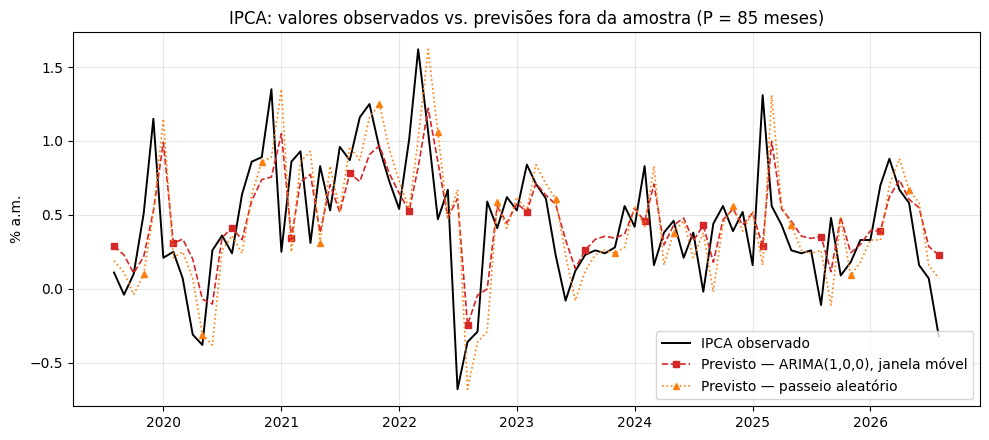

EQMP ARIMA(1,0,0) = 0.1338
EQMP passeio aleatorio = 0.1697


In [7]:
f_model = arima_pseudo_forecast(y, order=best_order, R=R, scheme="rolling", window_size=R, trend="c")
f_rw = random_walk_forecast(y, R)
y_true = y[R:]

fig, ax = plt.subplots()
ax.plot(dates_test, y_true, label="IPCA observado", color="black", lw=1.4)
ax.plot(dates_test, f_model, label="Previsto — ARIMA(1,0,0), janela móvel", color="tab:red", lw=1.2,
        ls="--", marker="s", ms=5, markevery=(0, 6))
ax.plot(dates_test, f_rw, label="Previsto — passeio aleatório", color="tab:orange", lw=1.2,
        ls=":", marker="^", ms=5, markevery=(3, 6))
ax.set_title("IPCA: valores observados vs. previsões fora da amostra (P = 85 meses)")
ax.set_ylabel("% a.m.")
ax.legend()
plt.tight_layout()
plt.show()

eqmp_model = np.mean((y_true - f_model) ** 2)
eqmp_rw = np.mean((y_true - f_rw) ** 2)
print(f"EQMP ARIMA(1,0,0) = {eqmp_model:.4f}")
print(f"EQMP passeio aleatorio = {eqmp_rw:.4f}")

O gráfico único acima sobrepõe o valor efetivamente observado do IPCA aos dois conjuntos de
previsão no período de avaliação. Visualmente, o passeio aleatório reage às variações do IPCA
apenas com uma defasagem de um período (por construção, ele "copia" o último valor observado),
o que o torna particularmente lento para captar o pico do choque inflacionário de 2021-22 e a
subsequente desinflação; o ARIMA(1,0,0) com janela móvel, por incorporar reversão à média,
amortece parte dessas oscilações e acompanha melhor as mudanças de patamar. Numericamente, o EQMP
do modelo ARIMA é menor que o do passeio aleatório, uma primeira evidência de ganho preditivo que
é testada formalmente a seguir.

### 1.7 Testes de Diebold-Mariano-West e de Clark-West

Testa-se $H_0:\sigma^2_{rw}=\sigma^2_{best}$ contra $H_1:\sigma^2_{rw}>\sigma^2_{best}$, com
valores críticos convencionais de uma distribuição $t$ com $P-1$ graus de liberdade.


In [8]:
res_dmw_q1 = dmw_test(y_true - f_rw, y_true - f_model)
res_cw_q1 = clark_west_test(y_true, f_rw, f_model)

resumo_q1 = pd.DataFrame({
    "Estatistica": [res_dmw_q1["stat"], res_cw_q1["stat"]],
    "p-valor": [res_dmw_q1["pvalue"], res_cw_q1["pvalue"]],
    "CV 10%": [res_dmw_q1["crit_values"][0.10], res_cw_q1["crit_values"][0.10]],
    "CV 5%": [res_dmw_q1["crit_values"][0.05], res_cw_q1["crit_values"][0.05]],
    "CV 1%": [res_dmw_q1["crit_values"][0.01], res_cw_q1["crit_values"][0.01]],
}, index=["DMW", "CW"])
resumo_q1


,Estatistica,p-valor,CV 10%,CV 5%,CV 1%
DMW,2.6838,0.0044,1.2917,1.6632,2.3716
CW,3.7607,0.0002,1.2917,1.6632,2.3716


Ambos os testes rejeitam $H_0$ a 1% de significância: a estatística DMW (2,68) e,
com folga ainda maior, a estatística CW (3,76) superam o valor crítico de 1% de uma
$t_{84}$ ($\approx 2{,}37$), com p-valores de 0,0044 e 0,0002, respectivamente. Conclui-se que o
ARIMA(1,0,0) estimado com janela móvel produz, neste período de avaliação, previsões
significativamente mais precisas do que o passeio aleatório para a inflação medida pelo IPCA.

Quanto à caracterização **aninhado/não-aninhado**: o passeio aleatório sem *drift* corresponde ao
caso particular $\phi_0=0,\phi_1=1$ do AR(1) geral estimado, de modo que, em princípio, esta é uma
comparação de modelos aninhados — o cenário exatamente motivador da correção de Clark-West.
Há, porém, uma sutileza: a restrição $\phi_1=1$ está na **fronteira** da região de
estacionariedade, e não no interior do espaço de parâmetros, de modo que a teoria assintótica
"padrão" de Clark-West (concebida originalmente para coeficientes nulos sobre regressores
adicionais, não para uma raiz unitária) se aplica apenas de forma aproximada a este caso
específico. Ainda assim, o fato de DMW e CW apontarem na mesma direção — com a CW, como esperado
sob aninhamento, produzindo uma estatística maior (mais favorável à rejeição de $H_0$) do que a
DMW — reforça a robustez da conclusão obtida, independentemente de qual aproximação assintótica
seja tomada de forma mais literal.


<a id="parte2"></a>
## Parte II — Questões 2, 3 e 4: simulação Monte Carlo

### 2. Geração da série simulada

Simula-se uma trajetória de $T=100$ observações do processo

$$y_t = 0{,}2 + 0{,}5\,y_{t-1} + \varepsilon_t,\qquad \varepsilon_t\ \overset{iid}{\sim}\ t(5),$$

com valor inicial igual à média incondicional do processo, $\mu=\phi_0/(1-\phi_1)=0{,}4$,
acrescida de uma inovação, como pede o enunciado. Usa-se uma semente aleatória fixa
(`seed=42`) para que os resultados sejam integralmente reprodutíveis.



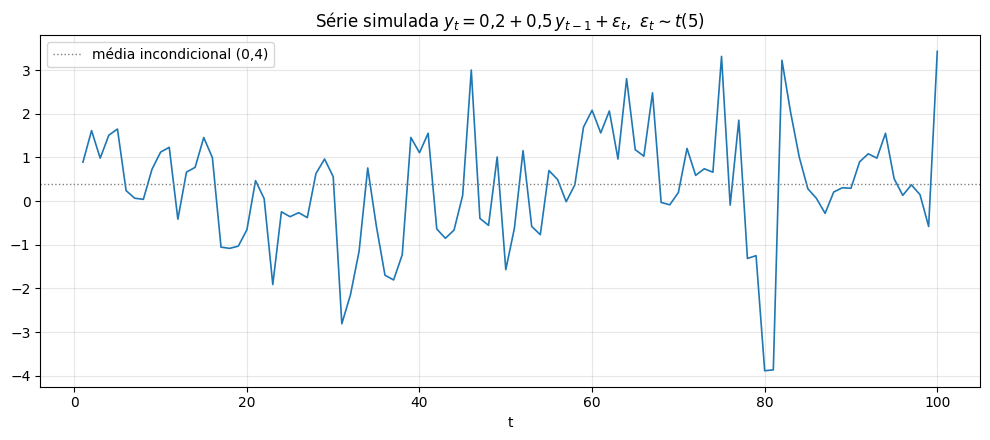

In [9]:
y_sim, eps_sim = simulate_ar1_student(n=100, phi0=0.2, phi1=0.5, df=5, seed=42)
t_idx = np.arange(1, 101)

fig, ax = plt.subplots()
ax.plot(t_idx, y_sim, color="tab:blue", lw=1.2)
ax.axhline(0.4, color="grey", ls=":", lw=1, label="média incondicional (0,4)")
ax.set_title(r"Série simulada $y_t = 0{,}2 + 0{,}5\,y_{t-1} + \varepsilon_t,\ \varepsilon_t\sim t(5)$")
ax.set_xlabel("t")
ax.legend()
plt.tight_layout()
plt.show()


### 3. Questão 2 — Previsão recursiva e gráfico único

Para $t=51,\dots,100$, geram-se previsões $1$-passo-à-frente recursivas (janela expansiva,
começando com $R=50$ observações) de três modelos: (i) um AR(1) com intercepto reestimado por
mínimos quadrados a cada novo ponto incorporado à janela; (ii) um passeio aleatório,
$\hat y_{t+1}=y_t$; e (iii) a previsão com os coeficientes verdadeiros do processo gerador,
$\hat y_{t+1}=0{,}2+0{,}5\,y_t$.


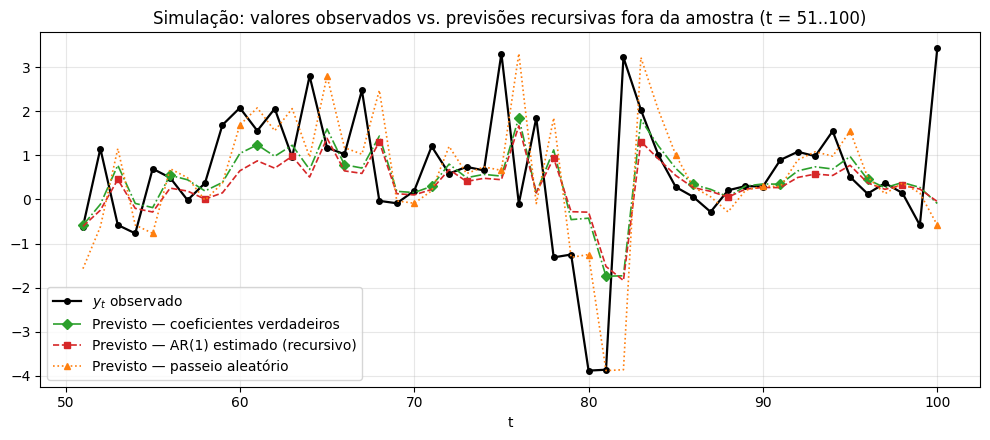

In [10]:
R_sim = 50
f_ar_sim, f_rw_sim, coefs_sim = recursive_forecasts_ar1(y_sim, R_sim)
f_true_sim = true_model_forecast(y_sim, R_sim, phi0=0.2, phi1=0.5)
y_target_sim = y_sim[R_sim:]
t_eval = t_idx[R_sim:]

fig, ax = plt.subplots()
ax.plot(t_eval, y_target_sim, label="$y_t$ observado", color="black", lw=1.6, marker="o", ms=4, markevery=1)
ax.plot(t_eval, f_true_sim, label="Previsto — coeficientes verdadeiros", color="tab:green", lw=1.2,
        ls="-.", marker="D", ms=5, markevery=(0, 5))
ax.plot(t_eval, f_ar_sim, label="Previsto — AR(1) estimado (recursivo)", color="tab:red", lw=1.2,
        ls="--", marker="s", ms=5, markevery=(2, 5))
ax.plot(t_eval, f_rw_sim, label="Previsto — passeio aleatório", color="tab:orange", lw=1.2,
        ls=":", marker="^", ms=5, markevery=(4, 5))
ax.set_title("Simulação: valores observados vs. previsões recursivas fora da amostra (t = 51..100)")
ax.set_xlabel("t")
ax.legend()
plt.tight_layout()
plt.show()

O gráfico único evidencia o padrão esperado: a previsão com coeficientes verdadeiros captura
corretamente a componente previsível da série — a reversão à média condicional —, mas, como
esperado de uma previsão ótima sob inovações de variância alta e cauda pesada ($t(5)$), não
acompanha de perto os desvios extremos da série observada nos instantes de choque (por exemplo,
em torno de $t\approx80$-$82$ e $t=100$): esses desvios são, por construção, a parte não-previsível
do processo, e nenhuma previsão $1$-passo-à-frente — nem mesmo a que usa os coeficientes
populacionais — poderia capturá-los; é "a melhor previsão possível" no sentido de minimizar o erro
quadrático médio, não no sentido de seguir de perto cada oscilação de $y_t$. O AR(1) estimado
recursivamente já converge, com $R=50$ observações iniciais, para coeficientes bastante próximos
dos verdadeiros, produzindo previsões muito semelhantes às do modelo "verdadeiro" — inclusive
durante os choques, as curvas verde e vermelha permanecem praticamente sobrepostas. Já o passeio
aleatório, por ignorar a reversão à média do processo (só "copia" o último valor, sem amortecê-lo),
reproduz cada choque observado com um período de atraso e sem nenhuma atenuação, ficando
sistematicamente mais disperso em torno da série observada, sobretudo após desvios grandes de
$y_t$ em relação à média incondicional.

### 4. Questão 3 — Testes de igualdade de EQMP (DMW e CW)

Com $\sigma_v^2$, $\sigma_{ar.est}^2$ e $\sigma_{rw}^2$ denotando os EQMPs do modelo verdadeiro, do
AR(1) estimado e do passeio aleatório, testam-se as três hipóteses do enunciado:

$$H_0:\sigma_{rw}^2=\sigma_{ar.est}^2 \ \text{ contra }\ H_1:\sigma_{rw}^2>\sigma_{ar.est}^2$$
$$H_0:\sigma_{rw}^2=\sigma_v^2 \ \text{ contra }\ H_1:\sigma_{rw}^2>\sigma_v^2$$
$$H_0:\sigma_v^2=\sigma_{ar.est}^2 \ \text{ contra }\ H_1:\sigma_v^2>\sigma_{ar.est}^2$$


In [11]:
e_true_sim = y_target_sim - f_true_sim
e_ar_sim = y_target_sim - f_ar_sim
e_rw_sim = y_target_sim - f_rw_sim

eqmp_true = np.mean(e_true_sim ** 2)
eqmp_ar = np.mean(e_ar_sim ** 2)
eqmp_rw = np.mean(e_rw_sim ** 2)
print(f"EQMP (verdadeiro)  sigma_v^2      = {eqmp_true:.4f}")
print(f"EQMP (AR estimado) sigma_ar.est^2 = {eqmp_ar:.4f}")
print(f"EQMP (passeio)     sigma_rw^2     = {eqmp_rw:.4f}")

pares = {
    "H0: rw = ar.est": (e_rw_sim, e_ar_sim, f_rw_sim, f_ar_sim),
    "H0: rw = v":      (e_rw_sim, e_true_sim, f_rw_sim, f_true_sim),
    "H0: v  = ar.est": (e_true_sim, e_ar_sim, f_true_sim, f_ar_sim),
}

linhas = []
for nome, (e1, e2, f1, f2) in pares.items():
    r_dmw = dmw_test(e1, e2)
    r_cw = clark_west_test(y_target_sim, f1, f2)
    linhas.append([nome, "DMW", r_dmw["stat"], r_dmw["pvalue"]])
    linhas.append([nome, "CW", r_cw["stat"], r_cw["pvalue"]])

resumo_q3 = pd.DataFrame(linhas, columns=["Hipotese", "Teste", "Estatistica", "p-valor"])
resumo_q3


EQMP (verdadeiro)  sigma_v^2      = 1.9507
EQMP (AR estimado) sigma_ar.est^2 = 2.0639
EQMP (passeio)     sigma_rw^2     = 2.8195


,Hipotese,Teste,Estatistica,p-valor
0,H0: rw = ar.est,DMW,1.3136,0.0976
1,H0: rw = ar.est,CW,2.1805,0.0170
2,H0: rw = v,DMW,1.5211,0.0673
3,H0: rw = v,CW,2.0690,0.0219
4,H0: v = ar.est,DMW,-1.9572,0.9720
5,H0: v = ar.est,CW,-1.4015,0.9163


Os resultados (ver tabela acima) ilustram de forma nítida o problema descrito na Seção 0.2.
Na comparação $H_0:\sigma_{rw}^2=\sigma_{ar.est}^2$ — uma comparação **aninhada**, no mesmo sentido
discutido para a Questão 1, já que o AR(1) estimado se reduz ao passeio aleatório no caso
particular $\phi_0=0,\phi_1=1$ — a estatística DMW (≈1,31, $p\approx0{,}10$) não rejeita $H_0$ a
5%, enquanto a estatística CW (≈2,18, $p\approx0{,}02$), que corrige o viés de estimação de
parâmetros, rejeita. O mesmo padrão se repete na comparação $H_0:\sigma_{rw}^2=\sigma_v^2$: DMW
não rejeita a 5% ($p\approx0{,}07$), mas rejeita a 10%; CW rejeita já a 5% ($p\approx0{,}02$). Como
o processo gerador de dados é conhecido nesta simulação, sabe-se de antemão que o passeio
aleatório *é*, de fato, um modelo pior (ele ignora a reversão à média presente no $\phi_1=0{,}5$
verdadeiro) — de modo que a estatística CW, ao rejeitar $H_0$ com mais facilidade, está acertando
com mais frequência a conclusão correta, exatamente o ganho de potência que a correção de
Clark-West se propõe a entregar em comparações aninhadas.

Já a terceira comparação, $H_0:\sigma_v^2=\sigma_{ar.est}^2$, não é uma comparação entre um modelo
e sua restrição aninhada, mas entre a mesma forma funcional avaliada com coeficientes populacionais
conhecidos versus estimados — isto é, mede-se apenas o custo do ruído de estimação paramétrica, e
não uma diferença de especificação. Tanto DMW quanto CW produzem estatísticas negativas e não
rejeitam $H_0$ (p-valores próximos de 1), resultado esperado: não há evidência de que o modelo
verdadeiro seja *pior* do que sua versão estimada — o mais razoável, dado que o modelo verdadeiro é
ótimo na população.

### 5. Questão 4 — Bootstrap semi-paramétrico

Constrói-se, por bootstrap semi-paramétrico com $B=1000$ réplicas (seguindo o procedimento
descrito na Seção 0.5), a distribuição sob $H_0:\sigma_{rw}^2=\sigma_{ar}^2$ das estatísticas DMW e
CW para a comparação RW vs. AR(1) estimado, e comparam-se os valores críticos e p-valores
empíricos com os obtidos por aproximação assintótica (Student) na Questão 3.


In [12]:
dmw_boot, cw_boot = semiparametric_bootstrap_rw_vs_ar(y_sim, R_sim, n_boot=1000, seed=123)

obs_dmw = dmw_test(e_rw_sim, e_ar_sim)["stat"]
obs_cw = clark_west_test(y_target_sim, f_rw_sim, f_ar_sim)["stat"]

resumo_dmw_boot = bootstrap_summary(obs_dmw, dmw_boot)
resumo_cw_boot = bootstrap_summary(obs_cw, cw_boot)

tabela_boot = pd.DataFrame({
    "Estatistica observada": [resumo_dmw_boot["observed"], resumo_cw_boot["observed"]],
    "CV boot 10%": [resumo_dmw_boot["crit_values"][0.10], resumo_cw_boot["crit_values"][0.10]],
    "CV boot 5%": [resumo_dmw_boot["crit_values"][0.05], resumo_cw_boot["crit_values"][0.05]],
    "CV boot 1%": [resumo_dmw_boot["crit_values"][0.01], resumo_cw_boot["crit_values"][0.01]],
    "p-valor boot": [resumo_dmw_boot["pvalue"], resumo_cw_boot["pvalue"]],
}, index=["DMW", "CW"])
tabela_boot


,Estatistica observada,CV boot 10%,CV boot 5%,CV boot 1%,p-valor boot
DMW,1.3136,0.5680,0.9777,1.6749,0.025
CW,2.1805,1.2985,1.5874,2.1127,0.008


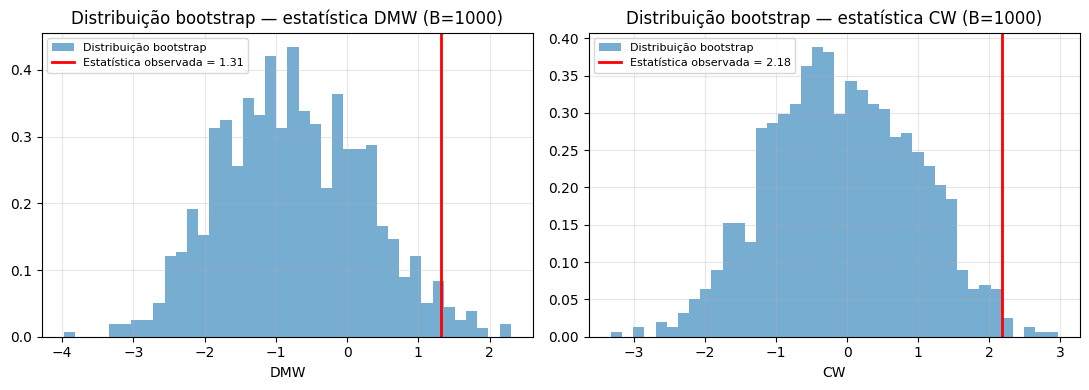

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, boot, obs, nome in zip(axes, [dmw_boot, cw_boot], [obs_dmw, obs_cw], ["DMW", "CW"]):
    ax.hist(boot, bins=40, density=True, color="tab:blue", alpha=0.6, label="Distribuição bootstrap")
    ax.axvline(obs, color="red", lw=2, label=f"Estatística observada = {obs:.2f}")
    ax.set_title(f"Distribuição bootstrap — estatística {nome} (B=1000)")
    ax.set_xlabel(nome)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


i) **Valores críticos.** Para a estatística DMW, os valores críticos empíricos a 10%, 5% e 1%
ficam em torno de 0,57, 0,98 e 1,67, respectivamente — bem abaixo dos valores convencionais de uma
$t_{49}$ (1,30 / 1,68 / 2,40) usados na Questão 3. Para a estatística CW, os valores críticos
bootstrap (≈1,30 / 1,59 / 2,11) também ficam abaixo dos convencionais, embora a diferença seja
menor do que no caso da DMW.

ii) **P-valor.** O p-valor bootstrap da estatística DMW observada (≈1,31) é de aproximadamente
0,025 — bem menor que o p-valor assintótico obtido na Questão 3 (≈0,10). O p-valor bootstrap da
estatística CW observada (≈2,18) é de aproximadamente 0,008, também menor que o p-valor assintótico
correspondente (≈0,02).

iii) **Distribuição da estatística de teste.** Os histogramas acima mostram que a distribuição
bootstrap de ambas as estatísticas sob $H_0$ é deslocada para a esquerda em relação à $t_{49}$
assintótica usada como referência convencional (média $\approx-0{,}75$ para a DMW e
$\approx-0{,}07$ para a CW, contra média 0 da referência) — precisamente o padrão descrito na
Seção 0.2 para comparações aninhadas, em que o ruído de estimação dos parâmetros extras do modelo
maior enviesa a estatística para baixo sob $H_0$. Vale notar que esse deslocamento é puramente de
**localização**, não de dispersão: o desvio-padrão da distribuição bootstrap
($\approx1{,}02$ para ambas as estatísticas) é praticamente idêntico ao da $t_{49}$ de referência
($\approx1{,}02$). São os valores críticos deslocados para a esquerda — e não uma distribuição
mais concentrada — que produzem os p-valores bootstrap menores do item (ii); a aproximação
assintótica convencional erra no centro da distribuição sob $H_0$ nesse cenário aninhado, não na
sua largura.

iv) **Conclusão sobre $H_0$.** Usando os valores críticos exatos (bootstrap) em vez dos
convencionais, rejeita-se $H_0:\sigma_{rw}^2=\sigma_{ar}^2$ a 5% (e mesmo a 1%, no caso da CW) —
uma conclusão mais forte do que a obtida com a estatística DMW e valores críticos assintóticos na
Questão 3, e consistente com a conclusão já obtida ali via CW. Isso confirma, em ambiente
controlado, o argumento teórico da Seção 0.2: em comparações que envolvem um modelo aninhado
(neste caso o passeio aleatório dentro do AR(1) estimado), a estatística DMW com valores críticos
assintóticos convencionais tende a **sub-rejeitar** $H_0$, e tanto a correção analítica de
Clark-West quanto a obtenção de valores críticos por bootstrap corrigem esse problema, levando a
inferências mais próximas da verdade conhecida do processo gerador de dados desta simulação (o
passeio aleatório é, de fato, um modelo inferior ao AR(1), verdadeiro ou estimado).


<a id="conclusao"></a>
## Conclusão

Os dois exercícios desta lista — um empírico, com dados reais de inflação (IPCA), e outro
controlado, com uma série simulada de processo gerador conhecido — convergem para a mesma lição
central sobre avaliação de previsões. Quando o modelo de referência (o passeio aleatório) está
aninhado no modelo concorrente, a estatística de Diebold-Mariano-West, mesmo sendo o teste
"natural" para comparar EQMPs, tende a ser conservadora demais, por conta do ruído de estimação dos
parâmetros extras do modelo maior. A estatística de Clark-West corrige analiticamente esse viés, e
o bootstrap semi-paramétrico oferece uma segunda forma, não-paramétrica, de chegar à mesma
correção, obtendo valores críticos e p-valores exatos em amostra finita. No caso do IPCA, DMW e CW
concordaram e rejeitaram fortemente a hipótese de igual capacidade preditiva, indicando que o
ARIMA(1,0,0) supera o passeio aleatório na previsão da inflação mensal no período avaliado; na
simulação, DMW e CW divergiram nas comparações envolvendo o passeio aleatório, e o exercício de
bootstrap da Questão 4 confirmou que a versão corrigida (CW, ou os valores críticos empíricos) leva
à conclusão correta com maior frequência, validando na prática a recomendação da literatura de
sempre preferir Clark-West — ou, na sua ausência, bootstrap — a Diebold-Mariano-West simples,
sempre que a comparação envolver modelos aninhados.
